## Difference between Tensor, Parameters and Linear Layer

## 1. Tensor (torch.Tensor)

A tensor is the fundamental data structure in PyTorch.

	•	It’s basically an n-dimensional array (like NumPy).
    
	•	It can store data and track gradients if requires_grad=True.

In [1]:
import torch

x = torch.tensor([[1.0, 2.0], [3.0, 4.0]], requires_grad=True)
print(type(x))  # torch.Tensor

<class 'torch.Tensor'>


### Fully correct training example and tie it directly to nn.Linear, Parameter, and gradients.


Step 1: Define a linear layer

import torch
import torch.nn as nn

layer = nn.Linear(1, 1)

Internally, this creates:
	•	layer.weight → nn.Parameter
	•	layer.bias → nn.Parameter

Both have:

requires_grad = True

So PyTorch will track them.

⸻

Step 2: Forward pass (build computation graph)

x = torch.tensor([[2.0]])
y_true = torch.tensor([[4.0]])

y_pred = layer(x)

What happens internally:

y_{\text{pred}} = xW^T + b

Graph becomes:

x → Linear(weight, bias) → y_pred


⸻

Step 3: Compute loss

loss = (y_pred - y_true) ** 2

Now graph expands:

x → Linear → y_pred → loss

PyTorch now knows:
	•	loss depends on y_pred
	•	y_pred depends on weight and bias

⸻

Step 4: Backward pass

loss.backward()

This is the critical moment.

PyTorch computes:
	•	∂loss / ∂weight
	•	∂loss / ∂bias

and stores them in:

layer.weight.grad
layer.bias.grad


⸻

Step 5: Inspect gradients

print(layer.weight.grad)
print(layer.bias.grad)

These are the signals telling how to change weights to reduce loss.

⸻

Step 6: Update weights (optimization step)

with torch.no_grad():
    layer.weight -= 0.01 * layer.weight.grad
    layer.bias -= 0.01 * layer.bias.grad

Why torch.no_grad()?
	•	Because updates should NOT be tracked in the computation graph

⸻

Step 7: Reset gradients

layer.weight.grad.zero_()
layer.bias.grad.zero_()

Important: gradients accumulate by default.

⸻

🔥 What just happened (connect everything)

1. nn.Linear
	•	Provided structure: y = xW^T + b

2. nn.Parameter
	•	weight and bias are trainable tensors
	•	Automatically tracked because requires_grad=True

3. requires_grad=True
	•	Enabled gradient computation through the graph

4. backward()
	•	Applied chain rule across the entire graph

⸻

🔬 The chain rule (what PyTorch is really doing)

For weight:

\frac{\partial loss}{\partial W}
=
\frac{\partial loss}{\partial y}
\cdot
\frac{\partial y}{\partial W}

PyTorch computes this automatically.

⸻

🧠 Clean mental model

During training:

Forward:
input → layer → prediction → loss

Backward:
loss → gradients → parameters

Update:
parameters ← parameters - lr * gradient


⸻

⚠️ Important subtle point

If weight were just a plain tensor:

self.weight = torch.randn(1, 1)

Then:
	•	It would NOT appear in model.parameters()
	•	Optimizer would ignore it
	•	No learning happens

⸻

Final intuition
	•	Tensor → carries values
	•	requires_grad=True → remembers how values were computed
	•	Parameter → marks tensors as learnable
	•	nn.Linear → packages Parameters + computation
	•	backward() → computes “how to fix errors”

⸻

## 2. Parameter (nn.Parameter)

A Parameter is a special kind of tensor.
    
	•	It is a subclass of torch.Tensor

	•	When assigned as an attribute of a nn.Module, it is automatically registered as a learnable parameter


In [3]:
import torch.nn as nn

param = nn.Parameter(torch.randn(2, 2))
print(type(param))  # torch.nn.parameter.Parameter
print(param)

<class 'torch.nn.parameter.Parameter'>
Parameter containing:
tensor([[ 0.7433,  1.0134],
        [-1.8498,  0.2518]], requires_grad=True)


### Inside a model:

In [4]:
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(2, 2))

model = MyModel()
print(list(model.parameters()))  # contains self.weight

[Parameter containing:
tensor([[ 0.2411,  0.0226],
        [-1.0000, -1.6055]], requires_grad=True)]


Key idea:

	•	nn.Parameter = Tensor that the model will learn (optimized)
    
	•	If you use a plain tensor instead, PyTorch will ignore it during training

## 3. Layer (nn.Linear)

nn.Linear is a module (layer) that internally uses Parameters.

Mathematically:

y = xW^T + b

In [6]:
layer = nn.Linear(in_features=3, out_features=2)

print(layer.weight.shape)  # (2, 3) # layer.weight.shape == (out_features, in_features)
print(layer.bias.shape)    # (2,)

torch.Size([2, 3])
torch.Size([2])


Intuition (this is the real insight)

Each output neuron needs:
	•	one weight per input feature

So:
	•	You have 2 output neurons
	•	Each needs 3 weights

→ total weight matrix = (2 neurons, 3 inputs) = (2, 3)

Weight is (2, 3) because:

You have 2 output neurons, and each neuron needs 3 weights (one per input feature).

    
    Internally:
	•	layer.weight → nn.Parameter
	•	layer.bias → nn.Parameter

Key idea:
	•	nn.Linear = predefined module containing Parameters + forward logic

If you’re building a neural network:

	•	Use Tensor → for inputs, temporary values
    
	•	Use Parameter → when you manually define weights
    
	•	Use nn.Linear → when you want a ready-made layer



# 🎯 Problem Statement

“Given a corpus of movie descriptions or titles, learn embeddings such that movies used in similar contexts are close in vector space.”

Example goal:

“Troll 2” ≈ “Gymkata”
“Avengers” ≈ “Iron Man”

## Small custom dataset:

"Troll 2 is a cult horror movie"

"Gymkata is a bizarre action movie"

"The Avengers is a superhero blockbuster"

"Iron Man is a Marvel superhero movie"


![Image](https://upload.wikimedia.org/wikipedia/commons/thumb/c/ce/Distributional_semantics.png/250px-Distributional_semantics.png)

![Image](https://de.mathworks.com/help/examples/textanalytics/win64/VisualizeWordEmbeddingsUsingTextScatterPlotsExample_01.png)

![Image](https://editor.analyticsvidhya.com/uploads/37840Screenshot%202021-06-18%20at%2012.19.48%20AM.png)

![Image](https://editor.analyticsvidhya.com/uploads/51054Screenshot%202021-06-18%20at%205.28.56%20PM.png)

![Image](https://i.sstatic.net/wVpAT.png)

## Distributional semantics

Distributional semantics is a linguistic and computational theory that models word meaning through patterns of word usage. It rests on the *distributional hypothesis*, which holds that words appearing in similar contexts tend to have similar meanings. This principle underlies many modern approaches in computational linguistics and cognitive modeling.

### Key facts

* **Core principle:** “You shall know a word by the company it keeps.”
* **Primary representations:** Vector space models derived from text corpora.
* **Foundational figures:** Zellig Harris and J. R. Firth.
* **Major applications:** Word embeddings, semantic similarity, information retrieval.
* **Modern extensions:** Contextualized neural embeddings such as BERT.

### The distributional hypothesis

First articulated by Zellig Harris in the 1950s and popularized by J. R. Firth, the hypothesis posits that linguistic meaning is reflected in distributional patterns of language use. If two words tend to occur in comparable syntactic and lexical environments, they are likely semantically related. This idea bridges empirical corpus data with theoretical semantics and has influenced both structural linguistics and modern natural language processing. ([HLT BME][1])

### Computational modeling

Distributional semantics operationalizes meaning as vectors in high-dimensional space, computed from co-occurrence statistics. Early models such as Latent Semantic Analysis and the Hyperspace Analogue to Language used linear algebra techniques (e.g., singular value decomposition) to reduce dimensionality. Later methods, including Word2Vec and GloVe, extended these ideas using neural networks to learn word embeddings that capture semantic similarity with remarkable accuracy. ([HLT BME][2])

### Compositional and cognitive aspects

Beyond isolated words, *compositional distributional semantics* seeks to model how phrase and sentence meanings emerge from their constituent words through algebraic or neural composition functions. The framework also has cognitive implications: it parallels human mechanisms of meaning generalization and has been used to study semantic change, polysemy, and concept formation. ([Emergent Mind][3])

### Applications and impact

Distributional semantic models underpin numerous natural language technologies, from search and translation to sentiment analysis and question answering. In theoretical linguistics, they provide quantitative tools for exploring meaning variation and the syntax–semantics interface. Recent research integrates distributional representations with visual and multimodal data, expanding the theory’s reach into grounded cognition and artificial intelligence. ([ScienceDirect][4])

[1]: https://static.hlt.bme.hu/semantics/external/pages/LSA/en.wikipedia.org/wiki/Distributional_semantics.html?utm_source=chatgpt.com "Distributional semantics - Wikipedia"
[2]: https://static.hlt.bme.hu/semantics/external/pages/Harris/en.wikipedia.org/wiki/Distributional_hypothesis.html?utm_source=chatgpt.com "Distributional semantics - Wikipedia"
[3]: https://www.emergentmind.com/articles/1905.01896?utm_source=chatgpt.com "Distributional Semantics in Linguistic Theory"
[4]: https://www.sciencedirect.com/science/article/pii/S0004370219300177?utm_source=chatgpt.com "Distributional semantics of objects in visual scenes in comparison to text - ScienceDirect"


1. Why does context define meaning?

Because of Distributional Semantics

2. Why do embeddings cluster?

Because optimization pushes:

Similar context → similar gradients → similar vectors

3. When do embeddings fail?
Small datasets → noisy vectors
Polysemy (“bat”) → confused embeddings
Bias in corpus → biased vectors


4. Why does dimension size matter?
Too small → underfitting
Too large → overfitting / meaningless space


📊 Evaluation Ideas (Don’t skip this — senior engineers don’t)

Quantitative

Cosine similarity 

Nearest neighbors

Qualitative

Print:
similar_words("troll")

## Import the modules that will do all the work

In [1]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.distributions.uniform import Uniform
from torch.utils.data import TensorDataset, DataLoader

import lightning as L

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Create the datasets that we will use for training the word embeddings

In [2]:
vocab = {
    "Troll 2": 0,
    "is": 1,
    "a": 2,
    "cult": 3,
    "horror": 4, 
    "movie": 5,
    "Gymkata": 6,
    "bizarre": 7,
    "action": 8,
    "The": 9,
    "Avengers": 10,
    "superhero": 11,
    "blockbuster": 12,
    "Iron Man": 13,
    "Marvel": 14
}

In [3]:
import torch

inputs = torch.tensor([
    # --- Sentence 1: troll 2 is a cult horror movie ---
    [0,1,1,0,0,0,0,0,0,0,0,0,0,0,0],  # context: [is, a] -> target: troll 2
    [1,0,1,1,0,0,0,0,0,0,0,0,0,0,0],  # context: [troll 2, a, cult] -> target: is
    [1,1,0,1,1,0,0,0,0,0,0,0,0,0,0],  # context: [troll 2, is, cult, horror] -> target: a
    [0,1,1,0,1,1,0,0,0,0,0,0,0,0,0],  # context: [is, a, horror, movie] -> target: cult
    [0,0,1,1,0,1,0,0,0,0,0,0,0,0,0],  # context: [a, cult, movie] -> target: horror
    [0,0,0,1,1,0,0,0,0,0,0,0,0,0,0],  # context: [cult, horror] -> target: movie

    # --- Sentence 2: Gymkata is a bizarre action movie ---
    [0,1,1,0,0,0,0,0,0,0,0,0,0,0,0],  # context: [is, a] -> target: Gymkata
    [0,0,1,0,0,0,1,1,0,0,0,0,0,0,0],  # context: [Gymkata, a, bizarre] -> target: is
    [0,1,0,0,0,0,1,1,1,0,0,0,0,0,0],  # context: [Gymkata, is, bizarre, action] -> target: a
    [0,1,1,0,0,1,0,0,1,0,0,0,0,0,0],  # context: [is, a, action, movie] -> target: bizarre
    [0,0,1,0,0,1,0,1,0,0,0,0,0,0,0],  # context: [a, bizarre, movie] -> target: action
    [0,0,0,0,0,0,0,1,1,0,0,0,0,0,0],  # context: [bizarre, action] -> target: movie

    # --- Sentence 3: The Avengers is a superhero blockbuster ---
    [0,1,0,0,0,0,0,0,0,0,1,0,0,0,0],  # context: [Avengers, is] -> target: The
    [0,1,1,0,0,0,0,0,0,1,0,0,0,0,0],  # context: [The, is, a] -> target: Avengers
    [0,0,1,0,0,0,0,0,0,1,1,1,0,0,0],  # context: [The, Avengers, a, superhero] -> target: is
    [0,1,0,0,0,0,0,0,0,0,1,0,1,0,0],  # context: [Avengers, is, superhero, blockbuster] -> target: a
    [0,1,1,0,0,0,0,0,0,0,0,0,1,0,0],  # context: [is, a, blockbuster] -> target: superhero
    [0,0,1,0,0,0,0,0,0,0,0,1,0,0,0],  # context: [a, superhero] -> target: blockbuster

    # --- Sentence 4: Iron Man is a Marvel superhero movie ---
    [0,1,1,0,0,0,0,0,0,0,0,0,0,0,0],  # context: [is, a] -> target: Iron Man
    [0,0,1,0,0,0,0,0,0,0,0,0,0,1,1],  # context: [Iron Man, a, Marvel] -> target: is
    [0,1,0,0,0,0,0,0,0,0,0,1,0,1,1],  # context: [Iron Man, is, Marvel, superhero] -> target: a
    [0,1,1,0,0,1,0,0,0,0,0,1,0,0,0],  # context: [is, a, superhero, movie] -> target: Marvel
    [0,0,1,0,0,1,0,0,0,0,0,0,0,0,1],  # context: [a, Marvel, movie] -> target: superhero
    [0,0,0,0,0,0,0,0,0,0,0,1,0,0,1]   # context: [Marvel, superhero] -> target: movie
], dtype=torch.float32)


labels = torch.tensor([
    # --- Sentence 1 targets ---
    [1,0,0,0,0,0,0,0,0,0,0,0,0,0,0],  # troll 2
    [0,1,0,0,0,0,0,0,0,0,0,0,0,0,0],  # is
    [0,0,1,0,0,0,0,0,0,0,0,0,0,0,0],  # a
    [0,0,0,1,0,0,0,0,0,0,0,0,0,0,0],  # cult
    [0,0,0,0,1,0,0,0,0,0,0,0,0,0,0],  # horror
    [0,0,0,0,0,1,0,0,0,0,0,0,0,0,0],  # movie

    # --- Sentence 2 targets ---
    [0,0,0,0,0,0,1,0,0,0,0,0,0,0,0],  # Gymkata
    [0,1,0,0,0,0,0,0,0,0,0,0,0,0,0],  # is
    [0,0,1,0,0,0,0,0,0,0,0,0,0,0,0],  # a
    [0,0,0,0,0,0,0,1,0,0,0,0,0,0,0],  # bizarre
    [0,0,0,0,0,0,0,0,1,0,0,0,0,0,0],  # action
    [0,0,0,0,0,1,0,0,0,0,0,0,0,0,0],  # movie

    # --- Sentence 3 targets ---
    [0,0,0,0,0,0,0,0,0,1,0,0,0,0,0],  # The
    [0,0,0,0,0,0,0,0,0,0,1,0,0,0,0],  # Avengers
    [0,1,0,0,0,0,0,0,0,0,0,0,0,0,0],  # is
    [0,0,1,0,0,0,0,0,0,0,0,0,0,0,0],  # a
    [0,0,0,0,0,0,0,0,0,0,0,1,0,0,0],  # superhero
    [0,0,0,0,0,0,0,0,0,0,0,0,1,0,0],  # blockbuster

    # --- Sentence 4 targets ---
    [0,0,0,0,0,0,0,0,0,0,0,0,0,1,0],  # Iron Man
    [0,1,0,0,0,0,0,0,0,0,0,0,0,0,0],  # is
    [0,0,1,0,0,0,0,0,0,0,0,0,0,0,0],  # a
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,1],  # Marvel
    [0,0,0,0,0,0,0,0,0,0,0,1,0,0,0],  # superhero
    [0,0,0,0,0,1,0,0,0,0,0,0,0,0,0]   # movie
], dtype=torch.float32)

## 📘 End-to-End Summary: One-Hot Encoding → Embeddings → Efficient Lookup

This note consolidates the full intuition, math, and implementation-level understanding we built step by step.

---

# 🎯 1. The Core Problem

Neural networks require **numeric vector inputs**, but language consists of **discrete symbols (words)**.

So we need a transformation:

```txt
word → number → vector
```

---

# 🔢 2. Index Encoding (First Step)

We assign each word a unique integer:

```txt
Vocabulary:
["troll_2", "hello", "world", "this", "is"]

Mapping:
troll_2 → 0
hello   → 1
world   → 2
this    → 3
is      → 4
```

This gives:

```python
X = [0, 4, 1]   # example input sequence
```

👉 But integers introduce **false ordering** (e.g., 4 > 0), which is meaningless.

---

# 🔥 3. One-Hot Encoding (Conceptual Breakthrough)

To remove ordering bias, we convert each index into a vector:

```txt
Vocab size (V) = 5

"is" (index 4) →
[0, 0, 0, 0, 1]
```

### Properties:

* Vector size = **V**
* Exactly **one 1**, rest **0**
* All words are **equally distant (orthogonal)**

---

# 🧠 4. Why One-Hot Exists

One-hot encoding provides:

### ✅ No unintended relationships

```txt
No ordering, no magnitude bias
```

### ✅ Clean mathematical structure

```txt
Each word = orthogonal basis vector
```

### ✅ Works with linear algebra

```txt
W @ one_hot = select specific vector
```

---

# ⚙️ 5. Embedding Matrix (W)

We introduce a learnable matrix:

```txt
W ∈ ℝ^(V × D)

Example:
V = 5 (vocab size)
D = 3 (embedding dimension)
```

```txt
W =
[
 [0.1, 0.2, 0.3],   ← troll_2
 [0.4, 0.5, 0.6],   ← hello
 [0.7, 0.8, 0.9],   ← world
 [1.0, 1.1, 1.2],   ← this
 [1.3, 1.4, 1.5]    ← is
]
```

👉 Each row = **vector representation (embedding) of a word**

---

# 🔴 6. Method 1: One-Hot + Matrix Multiplication

### Input:

```txt
"is" → index 4
one-hot = [0, 0, 0, 0, 1]
```

### Computation:

```txt
embedding = one_hot @ W
```

### Result:

```txt
embedding = [1.3, 1.4, 1.5]
```

---

# 🟢 7. Method 2: Embedding Lookup (`nn.Embedding`)

### Input:

```txt
index = 4
```

### Computation:

```python
embedding = W[4]
```

### Result:

```txt
[1.3, 1.4, 1.5]
```

---

# 🎯 8. Key Identity (CRITICAL)

```txt
one_hot @ W  ≡  W[index]
```

👉 Both methods are mathematically identical.

---

# 🔍 9. Batch Example

### Input:

```txt
["troll_2", "is", "hello"] → [0, 4, 1]
```

---

### One-hot version:

```txt
X =
[
 [1,0,0,0,0],
 [0,0,0,0,1],
 [0,1,0,0,0]
]
```

```txt
X @ W → (3 × 3)
```

---

### Embedding version:

```python
W[[0, 4, 1]]
```

---

### Output (same):

```txt
[
 [0.1, 0.2, 0.3],
 [1.3, 1.4, 1.5],
 [0.4, 0.5, 0.6]
]
```

---

# ⚡ 10. Efficiency Comparison

| Aspect          | One-Hot + MatMul | Embedding Lookup        |
| --------------- | ---------------- | ----------------------- |
| Input shape     | (V,)             | scalar index            |
| Matrix shape    | (V × D)          | (V × D)                 |
| Computation     | O(V)             | O(1)                    |
| Memory (input)  | Large            | Minimal                 |
| Operation       | Multiply + sum   | Direct indexing         |
| Gradient update | Dense            | Sparse (only used rows) |

---

# 🧠 11. Why One-Hot Feels Inefficient

### ❌ Problems:

* High dimensional (V can be 100k+)
* Mostly zeros (wasteful)
* No semantic meaning
* Slow computation

---

# 🚀 12. Why `nn.Embedding` is Better

Instead of:

```txt
build vector → multiply → extract
```

It does:

```txt
directly fetch row from W
```

---

### Under the hood:

* Uses **indexing / gather operations**
* Optimized in **C++ / CUDA**
* Updates only relevant rows during backprop

---

# 🔥 13. Deep Insight (Most Important Takeaway)

```txt
One-hot vector = selector
Embedding matrix W = actual knowledge
```

---

### So:

```txt
We are NOT learning one-hot vectors
We are learning W
```

---

# 🧠 14. Mental Model

```txt
W =
"table of word meanings in vector space"
```

```txt
W[index] =
"meaning of that word"
```

---

# ⚡ 15. Final Conceptual Shift

| Old Thinking       | Correct Thinking     |
| ------------------ | -------------------- |
| One-hot is input   | Index is input       |
| W is weights       | W is embedding space |
| Matmul is required | Lookup is enough     |

---

# 🚀 Final One-Line Takeaway

```txt
One-hot encoding is the mathematical foundation,
but embedding lookup is the efficient implementation.
```

---

# ✅ What You Now Understand

You now clearly understand:

* Why one-hot encoding was invented
* How it connects symbols → vectors
* How matrix multiplication selects embeddings
* Why `nn.Embedding` is equivalent but faster
* What W actually represents
* How real systems optimize computation

---

If you continue, the next step is the most important practical leap:

👉 **Step 6: Build the full neural network (embedding → prediction → loss → learning)**


In [4]:
dataset = TensorDataset(inputs, labels)
dataloader = DataLoader(dataset)

## Build and Train a Word Embedding Unit From Scratch

In [5]:
class WordEmbeddingFromScratch(L.LightningModule):


    def __init__(self):
        
        super().__init__()
    
        L.seed_everything(seed = 42)
    
        min_value = -0.25
        max_value = 0.25


        self.input1_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.input1_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
    
        self.input2_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.input2_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
    
        self.input3_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.input3_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
        
        self.input4_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.input4_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
        
        self.input5_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.input5_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
        
        self.input6_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.input6_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
        
        self.input7_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.input7_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
        
        self.input8_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.input8_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
        
        self.input9_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.input9_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
        
        self.input10_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.input10_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
        
        self.input11_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.input11_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
        
        self.input12_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.input12_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
        
        self.input13_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.input13_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
        
        self.input14_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.input14_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
        
        self.input15_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.input15_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
        
       
    
    
    
        self.output1_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.output1_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
        
        self.output2_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.output2_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
        
        self.output3_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.output3_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
        
        self.output4_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.output4_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
        
        self.output5_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.output5_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
        
        self.output6_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.output6_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
        
        self.output7_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.output7_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
        
        self.output8_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.output8_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
        
        self.output9_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.output9_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
        
        self.output10_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.output10_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
        
        self.output11_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.output11_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
        
        self.output12_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.output12_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
        
        self.output13_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.output13_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
        
        self.output14_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.output14_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
        
        self.output15_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.output15_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
        
        

        self.loss = nn.CrossEntropyLoss()



    def forward(self, input):
        
        input = input[0]
        inputs_to_top_hidden =  (
                                (input[0] * self.input1_w1) +
                                (input[1] * self.input2_w1) +
                                (input[2] * self.input3_w1) +
                                (input[3] * self.input4_w1) +
                                (input[4] * self.input5_w1) +
                                (input[5] * self.input6_w1) +
                                (input[6] * self.input7_w1) +
                                (input[7] * self.input8_w1) +
                                (input[8] * self.input9_w1) +
                                (input[9] * self.input10_w1) +
                                (input[10] * self.input11_w1) +
                                (input[11] * self.input12_w1) +
                                (input[12] * self.input13_w1) +
                                (input[13] * self.input14_w1) +
                                (input[14] * self.input15_w1)
                                )

        inputs_to_bottom_hidden = (
                                (input[0] * self.input1_w2) +
                                (input[1] * self.input2_w2) +
                                (input[2] * self.input3_w2) +
                                (input[3] * self.input4_w2) +
                                (input[4] * self.input5_w2) +
                                (input[5] * self.input6_w2) +
                                (input[6] * self.input7_w2) +
                                (input[7] * self.input8_w2) +
                                (input[8] * self.input9_w2) +
                                (input[9] * self.input10_w2) +
                                (input[10] * self.input11_w2) +
                                (input[11] * self.input12_w2) +
                                (input[12] * self.input13_w2) +
                                (input[13] * self.input14_w2) +
                                (input[14] * self.input15_w2)
                                )


        output1 = ((inputs_to_top_hidden * self.output1_w1) +
           (inputs_to_bottom_hidden * self.output1_w2))
        output2 = ((inputs_to_top_hidden * self.output2_w1) +
                   (inputs_to_bottom_hidden * self.output2_w2))
        output3 = ((inputs_to_top_hidden * self.output3_w1) +
                   (inputs_to_bottom_hidden * self.output3_w2))
        output4 = ((inputs_to_top_hidden * self.output4_w1) +
                   (inputs_to_bottom_hidden * self.output4_w2))
        output5 = ((inputs_to_top_hidden * self.output5_w1) +
                   (inputs_to_bottom_hidden * self.output5_w2))
        output6 = ((inputs_to_top_hidden * self.output6_w1) +
                   (inputs_to_bottom_hidden * self.output6_w2))
        output7 = ((inputs_to_top_hidden * self.output7_w1) +
                   (inputs_to_bottom_hidden * self.output7_w2))
        output8 = ((inputs_to_top_hidden * self.output8_w1) +
                   (inputs_to_bottom_hidden * self.output8_w2))
        output9 = ((inputs_to_top_hidden * self.output9_w1) +
                   (inputs_to_bottom_hidden * self.output9_w2))
        output10 = ((inputs_to_top_hidden * self.output10_w1) +
                    (inputs_to_bottom_hidden * self.output10_w2))
        output11 = ((inputs_to_top_hidden * self.output11_w1) +
                    (inputs_to_bottom_hidden * self.output11_w2))
        output12 = ((inputs_to_top_hidden * self.output12_w1) +
                    (inputs_to_bottom_hidden * self.output12_w2))
        output13 = ((inputs_to_top_hidden * self.output13_w1) +
                    (inputs_to_bottom_hidden * self.output13_w2))
        output14 = ((inputs_to_top_hidden * self.output14_w1) +
                    (inputs_to_bottom_hidden * self.output14_w2))
        output15 = ((inputs_to_top_hidden * self.output15_w1) +
                    (inputs_to_bottom_hidden * self.output15_w2))

        output_presoftmax = torch.stack([output1, output2, output3, output4, output5, output6, output7, output8, output9, output10, output11, output12, output13, output14, output15])
        


        return output_presoftmax



    def configure_optimizers(self):
        return Adam(self.parameters(), lr = 0.1)


    def training_step(self, batch):
        input_i, label_i = batch

        output_i = self.forward(input_i)

        loss = self.loss(output_i, label_i[0])

        return loss

    

In [6]:
modelFromScratch = WordEmbeddingFromScratch()

print("Before optimization, the parameters are...")
for name, param in modelFromScratch.named_parameters():
    print(name, torch.round(param.data, decimals = 2))

Seed set to 42


Before optimization, the parameters are...
input1_w1 tensor(0.1900)
input1_w2 tensor(0.2100)
input2_w1 tensor(-0.0600)
input2_w2 tensor(0.2300)
input3_w1 tensor(-0.0500)
input3_w2 tensor(0.0500)
input4_w1 tensor(-0.1200)
input4_w2 tensor(0.1500)
input5_w1 tensor(0.2200)
input5_w2 tensor(-0.1800)
input6_w1 tensor(0.2200)
input6_w2 tensor(0.0500)
input7_w1 tensor(0.1800)
input7_w2 tensor(0.0300)
input8_w1 tensor(0.1200)
input8_w2 tensor(-0.0400)
input9_w1 tensor(0.1900)
input9_w2 tensor(0.0400)
input10_w1 tensor(-0.1200)
input10_w2 tensor(0.0600)
input11_w1 tensor(-0.1200)
input11_w2 tensor(-0.0300)
input12_w1 tensor(-0.1000)
input12_w2 tensor(0.1700)
input13_w1 tensor(-0.2000)
input13_w2 tensor(-0.1200)
input14_w1 tensor(-0.0700)
input14_w2 tensor(-0.1500)
input15_w1 tensor(0.0200)
input15_w2 tensor(-0.2500)
output1_w1 tensor(0.2300)
output1_w2 tensor(-0.2100)
output2_w1 tensor(0.1900)
output2_w2 tensor(0.0400)
output3_w1 tensor(-0.0800)
output3_w2 tensor(0.1500)
output4_w1 tensor(0.040

In [7]:
data = {
    "w1": [
        modelFromScratch.input1_w1.item(),
        modelFromScratch.input2_w1.item(),
        modelFromScratch.input3_w1.item(),
        modelFromScratch.input4_w1.item(),
        modelFromScratch.input5_w1.item(),
        modelFromScratch.input6_w1.item(),
        modelFromScratch.input7_w1.item(),
        modelFromScratch.input8_w1.item(),
        modelFromScratch.input9_w1.item(),
        modelFromScratch.input10_w1.item(),
        modelFromScratch.input11_w1.item(),
        modelFromScratch.input12_w1.item(),
        modelFromScratch.input13_w1.item(),
        modelFromScratch.input14_w1.item(),
        modelFromScratch.input15_w1.item(),
    ],
    "w2": [
        modelFromScratch.input1_w2.item(),
        modelFromScratch.input2_w2.item(),
        modelFromScratch.input3_w2.item(),
        modelFromScratch.input4_w2.item(),
        modelFromScratch.input5_w2.item(),
        modelFromScratch.input6_w2.item(),
        modelFromScratch.input7_w2.item(),
        modelFromScratch.input8_w2.item(),
        modelFromScratch.input9_w2.item(),
        modelFromScratch.input10_w2.item(),
        modelFromScratch.input11_w2.item(),
        modelFromScratch.input12_w2.item(),
        modelFromScratch.input13_w2.item(),
        modelFromScratch.input14_w2.item(),
        modelFromScratch.input15_w2.item(),
    ],
    "token": [
        "Troll 2", "is", "a", "cult", "horror",
        "movie", "Gymkata", "bizarre", "action",
        "The", "Avengers", "superhero", "blockbuster",
        "Iron Man", "Marvel"
    ],
    "input": [f"input{i}" for i in range(1, 16)]
}

df = pd.DataFrame(data)
df

,w1,w2,token,input
0,0.191135,0.207502,Troll 2,input1
1,-0.058568,0.229653,is,input2
2,-0.054776,0.050448,a,input3
3,-0.121714,0.146821,cult,input4
4,0.220386,-0.183407,horror,input5
5,0.217299,0.046790,movie,input6
6,0.184702,0.033858,Gymkata,input7
7,0.120547,-0.035298,bizarre,input8
8,0.192721,0.036952,action,input9
9,-0.116710,0.063725,The,input10


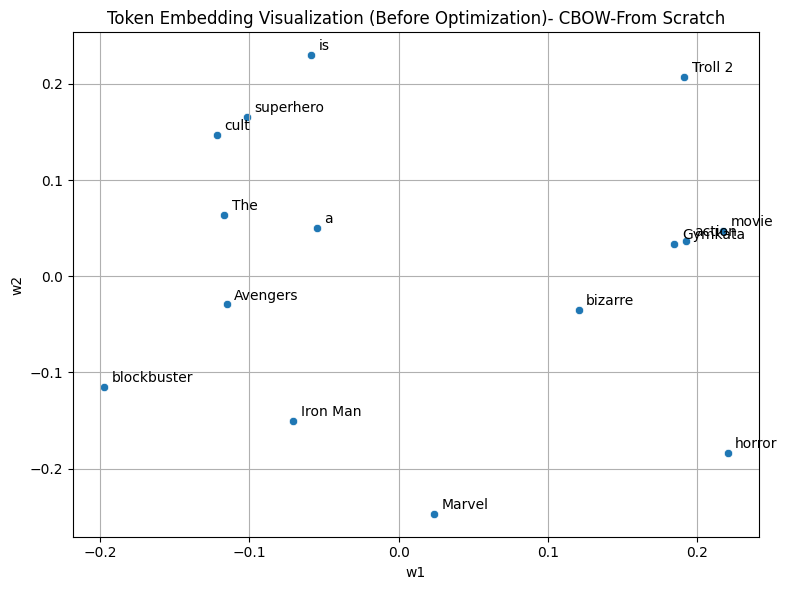

In [8]:
plt.figure(figsize=(8, 6))

sns.scatterplot(data=df, x="w1", y="w2")

# add labels with slight offset
for i in range(len(df)):
    plt.text(df.w1[i] + 0.005, df.w2[i] + 0.005, df.token[i],
             fontsize=10)

plt.xlabel("w1")
plt.ylabel("w2")
plt.title("Token Embedding Visualization (Before Optimization)- CBOW-From Scratch")

plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
trainer = L.Trainer(
    max_epochs=300,
    log_every_n_steps=5,
    enable_progress_bar=True
)
trainer.fit(modelFromScratch, train_dataloaders = dataloader)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ CrossEntropyLoss │      0 │ train │     0 │
│   │ other params │ n/a              │     60 │ n/a   │   n/a │
└───┴──────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 60                                                                                               
Non-trainable params: 0                                                                                            
Total params: 60                                                                                                   
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 1                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
`Trainer.fit` stopped: `max_epochs=300` reached.


## After Training 300 epoch

In [10]:
data = {
    "w1": [
        modelFromScratch.input1_w1.item(),
        modelFromScratch.input2_w1.item(),
        modelFromScratch.input3_w1.item(),
        modelFromScratch.input4_w1.item(),
        modelFromScratch.input5_w1.item(),
        modelFromScratch.input6_w1.item(),
        modelFromScratch.input7_w1.item(),
        modelFromScratch.input8_w1.item(),
        modelFromScratch.input9_w1.item(),
        modelFromScratch.input10_w1.item(),
        modelFromScratch.input11_w1.item(),
        modelFromScratch.input12_w1.item(),
        modelFromScratch.input13_w1.item(),
        modelFromScratch.input14_w1.item(),
        modelFromScratch.input15_w1.item(),
    ],
    "w2": [
        modelFromScratch.input1_w2.item(),
        modelFromScratch.input2_w2.item(),
        modelFromScratch.input3_w2.item(),
        modelFromScratch.input4_w2.item(),
        modelFromScratch.input5_w2.item(),
        modelFromScratch.input6_w2.item(),
        modelFromScratch.input7_w2.item(),
        modelFromScratch.input8_w2.item(),
        modelFromScratch.input9_w2.item(),
        modelFromScratch.input10_w2.item(),
        modelFromScratch.input11_w2.item(),
        modelFromScratch.input12_w2.item(),
        modelFromScratch.input13_w2.item(),
        modelFromScratch.input14_w2.item(),
        modelFromScratch.input15_w2.item(),
    ],
    "token": [
        "Troll 2", "is", "a", "cult", "horror",
        "movie", "Gymkata", "bizarre", "action",
        "The", "Avengers", "superhero", "blockbuster",
        "Iron Man", "Marvel"
    ],
    "input": [f"input{i}" for i in range(1, 16)]
}

df = pd.DataFrame(data)
df

,w1,w2,token,input
0,4.599646,8.713837,Troll 2,input1
1,-7.136100,5.462316,is,input2
2,5.884936,-6.895819,a,input3
3,-0.041963,1.537598,cult,input4
4,3.350732,2.578867,horror,input5
5,-9.076996,-3.812341,movie,input6
6,-1.120028,12.184547,Gymkata,input7
7,5.899313,1.752860,bizarre,input8
8,1.362036,10.251694,action,input9
9,11.670359,1.214799,The,input10


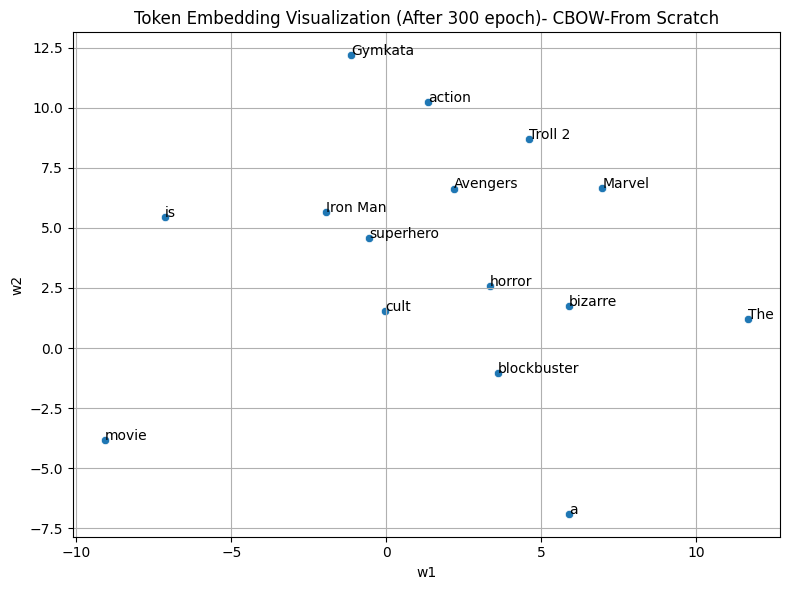

In [11]:
plt.figure(figsize=(8, 6))

sns.scatterplot(data=df, x="w1", y="w2")

# add labels with slight offset
for i in range(len(df)):
    plt.text(df.w1[i] + 0.005, df.w2[i] + 0.005, df.token[i],
             fontsize=10)

plt.xlabel("w1")
plt.ylabel("w2")
plt.title("Token Embedding Visualization (After 300 epoch)- CBOW-From Scratch")

plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
example = inputs[3].unsqueeze(0)  # shape (1, 15)

print(torch.round(softmax(modelFromScratch(example)), decimals=2))

NameError: name 'softmax' is not defined

## Build and train a word embedding unit using nn.Linear()

### Concept:

Statement:

* In basic word embedding models, you typically do not use an activation function in the hidden layer.
* But you do use Softmax at the output layer.
* In larger or modern models, activations are used again.

⸻

Example 1: Simple word embedding (like your model or Word2Vec)

Flow:

input (one-hot or context vector)
   → linear weights (embedding lookup)
   → output scores
   → Softmax → probabilities

* Hidden layer: ❌ no activation
* Output layer: ✅ Softmax

👉 Intuition: you’re just learning a vector for each word, not doing complex transformations.

⸻

Example 2: Your current model

You are doing:

input → weighted sum → output → Softmax

* No activation in between → ✔️ correct for this setup
* Softmax at the end → ✔️ needed to get probabilities

⸻

Example 3: Modern NLP model (like BERT)

Flow:

input → embeddings → multiple layers (with ReLU/GELU) → output → Softmax

* Hidden layers: ✅ activation functions (many)
* Output layer: ✅ Softmax

👉 These models learn much more complex patterns, so they need non-linearity.

⸻

Final takeaway (simple):

* If you’re just learning word vectors → no hidden activation needed
* If you’re building a deep model using embeddings → activation functions are used

Your current implementation is perfectly aligned with the first case.

In [13]:
class WordEmbeddingWithLinear(L.LightningModule):
    def __init__(self):
        super().__init__()

        L.seed_everything(seed = 42)
        self.input_to_hidden = nn.Linear(in_features = 15, out_features = 5, bias = False)
        self.hidden_to_output = nn.Linear(in_features = 5, out_features = 15, bias = False)

        self.loss = nn.CrossEntropyLoss()


    def forward(self, input):
        hidden = self.input_to_hidden(input)
        output_values = self.hidden_to_output(hidden)
        return output_values

    def configure_optimizers(self):
        return Adam(self.parameters(), lr = 0.05)

    def training_step(self, batch):
        input_i, label_i = batch
        output_i = self.forward(input_i)
        loss = self.loss(output_i, label_i)

        return loss

        

In [14]:
modelLinear = WordEmbeddingWithLinear()

print("Before optimization, the parameters are...")
for name, param in modelLinear.named_parameters():
    print(name, torch.round(param.data, decimals = 2))

Seed set to 42


Before optimization, the parameters are...
input_to_hidden.weight tensor([[ 0.2000,  0.2100, -0.0600,  0.2400, -0.0600,  0.0500, -0.1300,  0.1500,
          0.2300, -0.1900,  0.2200,  0.0500,  0.1900,  0.0300,  0.1200],
        [-0.0400,  0.2000,  0.0400, -0.1200,  0.0700, -0.1200, -0.0300, -0.1000,
          0.1700, -0.2000, -0.1200, -0.0700, -0.1600,  0.0200, -0.2600],
        [ 0.2300, -0.2200,  0.2000,  0.0400, -0.0800,  0.1600,  0.0400,  0.2100,
          0.0300, -0.0800,  0.0700, -0.0700,  0.1100,  0.2300,  0.1500],
        [-0.1100,  0.1500,  0.0500,  0.1300, -0.1600, -0.2600, -0.1000, -0.2000,
          0.2100,  0.0700,  0.1100,  0.0800, -0.0000,  0.2000, -0.1800],
        [ 0.0200, -0.1800,  0.0800, -0.0900,  0.0800, -0.0500,  0.2100, -0.1500,
         -0.1500, -0.1500,  0.2300,  0.0900,  0.2500, -0.2100, -0.2600]])
hidden_to_output.weight tensor([[-0.3500, -0.3000,  0.1800,  0.1600,  0.3700],
        [-0.2300, -0.3000,  0.2400, -0.1800,  0.2700],
        [-0.1100,  0.2600, -0

In [15]:
data = {
    ## NOTE: Unlike before, when we called item() on each individual
    ##       Weight, now that we are using nn.Linear, we access the
    ##       Weights with ".weight". We then have to remove the gradients
    ##       associated with each Weight, so we also call .detach().
    ##       Lastly, we then convert the tensor to a numpy array with
    ##       numpy().
    "w1": modelLinear.input_to_hidden.weight.detach()[0].numpy(), # [0] = Weights to top activation function
    "w2": modelLinear.input_to_hidden.weight.detach()[1].numpy(), # [1] = Weights to bottom activation function
    "token": [

        "Troll 2", "is", "a", "cult", "horror",

        "movie", "Gymkata", "bizarre", "action",

        "The", "Avengers", "superhero", "blockbuster",

        "Iron Man", "Marvel"

    ],

    "input": [f"input{i}" for i in range(1, 16)]
}
df = pd.DataFrame(data)
df

,w1,w2,token,input
0,0.197403,-0.036455,Troll 2,input1
1,0.214307,0.199042,is,input2
2,-0.060489,0.038164,a,input3
3,0.237184,-0.120538,cult,input4
4,-0.056572,0.065814,horror,input5
5,0.052102,-0.118962,movie,input6
6,-0.125705,-0.030280,Gymkata,input7
7,0.151636,-0.104870,bizarre,input8
8,0.227613,0.171282,action,input9
9,-0.189422,-0.203815,The,input10


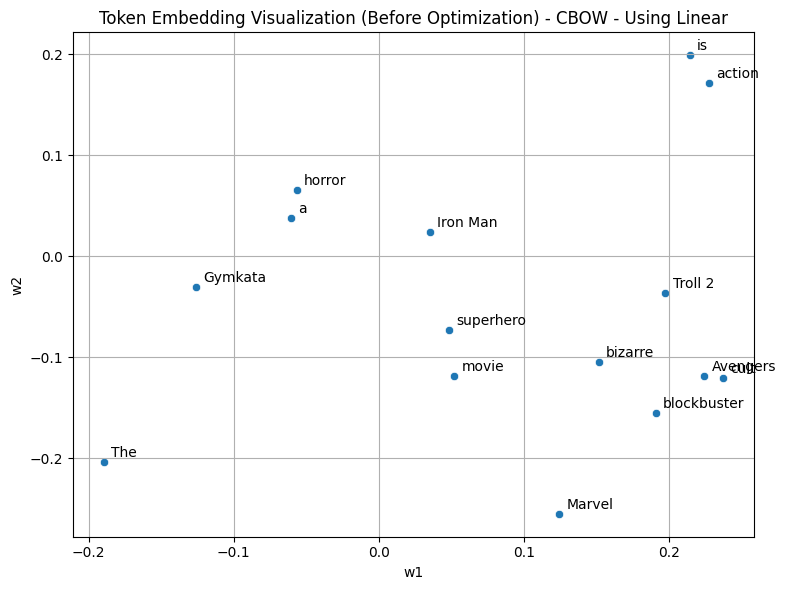

In [16]:
plt.figure(figsize=(8, 6))

sns.scatterplot(data=df, x="w1", y="w2")

# add labels with slight offset
for i in range(len(df)):
    plt.text(df.w1[i] + 0.005, df.w2[i] + 0.005, df.token[i],
             fontsize=10)

plt.xlabel("w1")
plt.ylabel("w2")
plt.title("Token Embedding Visualization (Before Optimization) - CBOW - Using Linear")

plt.grid(True)
plt.tight_layout()
plt.show()

In [17]:
trainer = L.Trainer(max_epochs = 300)
trainer.fit(modelLinear, train_dataloaders = dataloader)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ input_to_hidden  │ Linear           │     75 │ train │     0 │
│ 1 │ hidden_to_output │ Linear           │     75 │ train │     0 │
│ 2 │ loss             │ CrossEntropyLoss │      0 │ train │     0 │
└───┴──────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 150                                                                                              
Non-trainable params: 0                                                                                            
Total params: 150                                                                                                  
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 3                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:317: The number of training batches (24) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
`Trainer.fit` stopped: `max_epochs=300` reached.


In [18]:
data = {
    ## NOTE: Unlike before, when we called item() on each individual
    ##       Weight, now that we are using nn.Linear, we access the
    ##       Weights with ".weight". We then have to remove the gradients
    ##       associated with each Weight, so we also call .detach().
    ##       Lastly, we then convert the tensor to a numpy array with
    ##       numpy().
    "w1": modelLinear.input_to_hidden.weight.detach()[0].numpy(), # [0] = Weights to top activation function
    "w2": modelLinear.input_to_hidden.weight.detach()[1].numpy(), # [1] = Weights to bottom activation function
    "token": [

        "Troll 2", "is", "a", "cult", "horror",

        "movie", "Gymkata", "bizarre", "action",

        "The", "Avengers", "superhero", "blockbuster",

        "Iron Man", "Marvel"

    ],

    "input": [f"input{i}" for i in range(1, 16)]
}
df = pd.DataFrame(data)
df

,w1,w2,token,input
0,4.074294,-3.228412,Troll 2,input1
1,1.626617,2.040370,is,input2
2,-2.361479,-2.237743,a,input3
3,-0.553904,2.117237,cult,input4
4,-0.876473,3.674104,horror,input5
5,-0.523632,1.986907,movie,input6
6,2.874523,0.422704,Gymkata,input7
7,1.484250,-4.278409,bizarre,input8
8,5.913060,2.990149,action,input9
9,-0.958597,-3.621313,The,input10


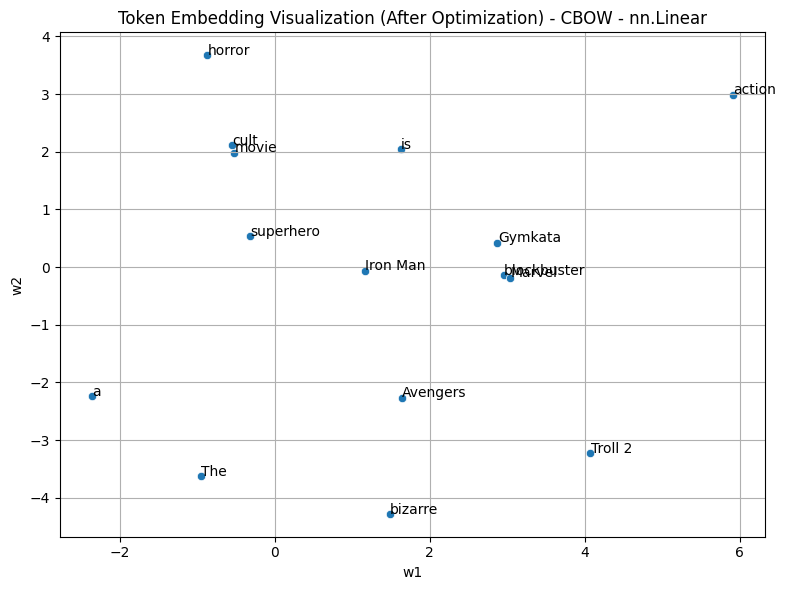

In [19]:
plt.figure(figsize=(8, 6))

sns.scatterplot(data=df, x="w1", y="w2")

# add labels with slight offset
for i in range(len(df)):
    plt.text(df.w1[i] + 0.005, df.w2[i] + 0.005, df.token[i],
             fontsize=10)

plt.xlabel("w1")
plt.ylabel("w2")
plt.title("Token Embedding Visualization (After Optimization) - CBOW - nn.Linear")

plt.grid(True)
plt.tight_layout()
plt.show()

## Issues

Yes—internally they’re doing the same kind of math, but there’s an important structural difference.

⸻

Core idea (clean intuition)

Both your custom model and nn.Linear are doing:

weighted sums → produce a vector → use it for prediction

So at a low level:

* Your manual weights (input1_w1, etc.)
* nn.Linear.weight

are functionally equivalent operations

⸻

Why they feel different in behavior

Your custom model:

* Each word has independent parameters
* Example:

input3_w1, input3_w2

    belong only to that token

👉 Think: each word owns its own coordinates

⸻

nn.Linear model:

nn.Linear(15, 2)

* All words share a single weight matrix
* Each word corresponds to a column in that matrix

👉 Think: all words are embedded through one shared transformation

⸻

Key difference (this is the real reason behavior changes)

* Custom model → no coupling between words
* Linear model → all words are coupled

So when training:

* Updating one word in custom model → affects only that word
* Updating in linear model → affects entire embedding space

⸻

Why both are still “word embeddings”

Even with nn.Linear:

* Input is one-hot → selects one column
* That column = embedding vector

So yes:

✅ nn.Linear is effectively an embedding layer
(just written in a general matrix form)

⸻

Subtle but important insight

What you built manually is closer to:

nn.Embedding(num_embeddings=15, embedding_dim=2)

What you replaced it with is:

nn.Linear(15, 2)

They behave similarly only because your input is one-hot.

⸻

Final takeaway

* ✔ Both approaches compute embeddings
* ✔ Both are mathematically similar
* ❗ But nn.Linear introduces shared structure + constraints

That’s why:

* Your old model gave “nicer” clusters
* The new one is more realistic but constrained

⸻

If you want the best of both worlds, the most standard approach is:

nn.Embedding(15, 2)

That behaves exactly like your original custom model—but cleaner and scalable.

## Use nn.Embedding() to load and use pre-trained Word Embeddings

In [128]:
word_embeddings = nn.Embedding.from_pretrained(modelLinear.input_to_hidden.weight.T)

In [129]:
word_embeddings.weight

Parameter containing:
tensor([[ 4.0743, -3.2284, -0.4147,  2.6507, -1.0704],
        [ 1.6266,  2.0404, -2.8704,  1.5112,  0.0221],
        [-2.3615, -2.2377,  2.1413, -0.1624, -0.2579],
        [-0.5539,  2.1172,  2.8163, -0.7058,  3.1146],
        [-0.8765,  3.6741,  1.6211, -1.4632,  7.2626],
        [-0.5236,  1.9869, -1.6223,  1.2496, -4.5010],
        [ 2.8745,  0.4227,  2.3958,  3.1756,  2.4952],
        [ 1.4843, -4.2784, -1.1832, -2.0553,  2.1168],
        [ 5.9131,  2.9901,  2.1613, -2.6838,  1.9895],
        [-0.9586, -3.6213,  2.0253,  3.1282,  6.2415],
        [ 1.6382, -2.2657, -2.2852, -3.8476,  3.5292],
        [-0.3200,  0.5333,  0.0121, -1.8837,  0.0738],
        [ 2.9549, -0.1362,  4.5645,  2.3822, -0.8880],
        [ 1.1602, -0.0610,  0.1833,  1.5314,  2.8202],
        [ 3.0343, -0.1828,  1.2457, -0.9754,  0.0242]])

In [130]:
token_to_embedding = {'Troll 2': 0,
                      'is' : 1}

print(word_embeddings(torch.tensor(token_to_embedding['Troll 2'])))

tensor([ 4.0743, -3.2284, -0.4147,  2.6507, -1.0704])


## Build and train a word embedding unit using nn.Embedding() and nn.Linear()

In [20]:
class WordEmbedingWithEmbedding(L.LightningModule):
    def __init__(self):
        super().__init__()
        L.seed_everything(seed=42)

        self.embed = nn.Embedding(15, 10)
        self.hidden_to_output = nn.Linear(10, 15, bias=False)

        self.loss = nn.CrossEntropyLoss()

    def forward(self, input):
        hidden = self.embed(input)
        output_values = self.hidden_to_output(hidden)
        return output_values

    def configure_optimizers(self):
        return Adam(self.parameters(), lr=0.01)

    def training_step(self, batch):
        input_i, label_i = batch

        output_i = self(input_i)
        loss = self.loss(output_i, label_i)

        return loss

In [21]:
inputsForEmbed = torch.tensor([[0], [1], [2], [3], [4], [5], [6], [7], [8], [9], [10], [11], [12], [13], [14]])

In [22]:
import torch

sentences = [

    ["Troll 2", "is", "a", "cult", "horror", "movie"],

    ["Gymkata", "is", "a", "bizarre", "action", "movie"],

    ["The", "Avengers", "is", "a", "superhero", "blockbuster"],

    ["Iron Man", "is", "a", "Marvel", "superhero", "movie"]

]

vocab = {

    "Troll 2": 0, "is": 1, "a": 2, "cult": 3, "horror": 4, "movie": 5,

    "Gymkata": 6, "bizarre": 7, "action": 8,

    "The": 9, "Avengers": 10, "superhero": 11, "blockbuster": 12,

    "Iron Man": 13, "Marvel": 14

}

window = 2

inputs = []

labels = []

for s in sentences:

    idxs = [vocab[w] for w in s]

    for i in range(len(idxs)):

        center = idxs[i]

        for j in range(max(0, i - window), min(len(idxs), i + window + 1)):

            if i != j:

                inputs.append(center)

                labels.append(idxs[j])

inputs = torch.tensor(inputs)

labels = torch.tensor(labels)

print("inputs : ", inputs)

inputs :  tensor([ 0,  0,  1,  1,  1,  2,  2,  2,  2,  3,  3,  3,  3,  4,  4,  4,  5,  5,
         6,  6,  1,  1,  1,  2,  2,  2,  2,  7,  7,  7,  7,  8,  8,  8,  5,  5,
         9,  9, 10, 10, 10,  1,  1,  1,  1,  2,  2,  2,  2, 11, 11, 11, 12, 12,
        13, 13,  1,  1,  1,  2,  2,  2,  2, 14, 14, 14, 14, 11, 11, 11,  5,  5])


In [23]:
datasetForEmbed = TensorDataset(inputs, labels)
dataloaderForEmbed = DataLoader(datasetForEmbed)

In [24]:
modelEmbed = WordEmbedingWithEmbedding()

print("Before optimization, the parameters are...")

weights = modelEmbed.embed.weight.detach().numpy()
print(weights)

w1 = [ weight[0] for weight in weights]
w2 = [ weight[1] for weight in weights]


Seed set to 42


Before optimization, the parameters are...
[[ 1.9269150e+00  1.4872842e+00  9.0071720e-01 -2.1055214e+00
   6.7841846e-01 -1.2345450e+00 -4.3067481e-02 -1.6046669e+00
  -7.5213617e-01  1.6487229e+00]
 [-3.9247864e-01 -1.4036068e+00 -7.2788125e-01 -5.5942988e-01
  -7.6883894e-01  7.6244539e-01  1.6423169e+00 -1.5959732e-01
  -4.9739748e-01  4.3958923e-01]
 [-7.5813115e-01  1.0783176e+00  8.0080050e-01  1.6806206e+00
   1.2791244e+00  1.2964228e+00  6.1046648e-01  1.3347378e+00
  -2.3162432e-01  4.1759491e-02]
 [-2.5157526e-01  8.5985851e-01 -1.3846742e+00 -8.7123615e-01
  -2.2336593e-01  1.7173611e+00  3.1887972e-01 -4.2451897e-01
   3.0572033e-01 -7.7459252e-01]
 [-1.5575722e+00  9.9563611e-01 -8.7978584e-01 -6.0114294e-01
  -1.2741514e+00  2.1227851e+00 -1.2346534e+00 -4.8791388e-01
  -9.1382301e-01 -6.5813726e-01]
 [ 7.8023873e-02  5.2580875e-01 -4.8799172e-01  1.1913692e+00
  -8.1400764e-01 -7.3599285e-01 -1.4032478e+00  3.6003824e-02
  -6.3477270e-02  6.7561489e-01]
 [-9.7806893e-0

## Logic
“PCA projects high-dimensional embeddings into a lower-dimensional space by selecting directions of maximum variance, allowing us to visualize semantic relationships while preserving as much structure as possible.”

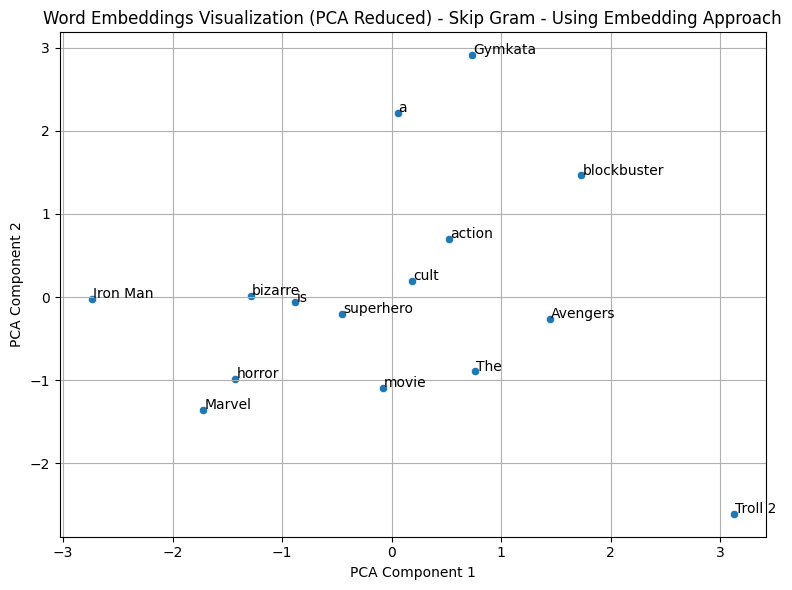

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.decomposition import PCA

# 1. Extract embeddings
weights = modelEmbed.embed.weight.detach().cpu().numpy()

# 2. Apply PCA (10D → 2D)
pca = PCA(n_components=2)
reduced = pca.fit_transform(weights)

# 3. Build dataframe
tokens = list(vocab.keys())

df = pd.DataFrame({
    "token": tokens,
    "w1": reduced[:, 0],
    "w2": reduced[:, 1]
})

# 4. Plot
plt.figure(figsize=(8, 6))

sns.scatterplot(data=df, x="w1", y="w2")

# annotate points
for i in range(len(df)):
    plt.text(df["w1"][i] + 0.01,
             df["w2"][i] + 0.01,
             df["token"][i],
             fontsize=10)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Word Embeddings Visualization (PCA Reduced) - Skip Gram - Using Embedding Approach")

plt.grid(True)
plt.tight_layout()
plt.show()


In [27]:
print(w1, w2)

[np.float32(1.926915), np.float32(-0.39247864), np.float32(-0.75813115), np.float32(-0.25157526), np.float32(-1.5575722), np.float32(0.07802387), np.float32(-0.09780689), np.float32(-1.0545899), np.float32(0.010868144), np.float32(-1.0494658), np.float32(0.6407553), np.float32(-0.0013108636), np.float32(-0.012685479), np.float32(-1.4364065), np.float32(-0.4257231)] [np.float32(1.4872842), np.float32(-1.4036068), np.float32(1.0783176), np.float32(0.8598585), np.float32(0.9956361), np.float32(0.52580875), np.float32(1.844594), np.float32(1.2779951), np.float32(-0.3387426), np.float32(0.6038988), np.float32(0.5832474), np.float32(-0.30360365), np.float32(0.24083632), np.float32(-1.1298598), np.float32(-1.337147)]


In [28]:
import pandas as pd

tokens = list(vocab.keys())

w1 = [weights[vocab[w]][0] for w in tokens]
w2 = [weights[vocab[w]][1] for w in tokens]

data = {
    "token": tokens,
    "w1": w1,
    "w2": w2
}

df = pd.DataFrame(data)
df

,token,w1,w2
0,Troll 2,1.926915,1.487284
1,is,-0.392479,-1.403607
2,a,-0.758131,1.078318
3,cult,-0.251575,0.859859
4,horror,-1.557572,0.995636
5,movie,0.078024,0.525809
6,Gymkata,-0.097807,1.844594
7,bizarre,-1.054590,1.277995
8,action,0.010868,-0.338743
9,The,-1.049466,0.603899


In [29]:
trainer = L.Trainer(max_epochs=300)
trainer.fit(modelEmbed, train_dataloaders=dataloaderForEmbed)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ embed            │ Embedding        │    150 │ train │     0 │
│ 1 │ hidden_to_output │ Linear           │    150 │ train │     0 │
│ 2 │ loss             │ CrossEntropyLoss │      0 │ train │     0 │
└───┴──────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 300                                                                                              
Non-trainable params: 0                                                                                            
Total params: 300                                                                                                  
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 3                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
`Trainer.fit` stopped: `max_epochs=300` reached.


In [30]:
weights = modelEmbed.embed.weight.detach().cpu().numpy()

In [31]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced = pca.fit_transform(weights)

In [32]:
import pandas as pd

tokens = list(vocab.keys())

df = pd.DataFrame({
    "token": tokens,
    "w1": reduced[:, 0],
    "w2": reduced[:, 1]
})

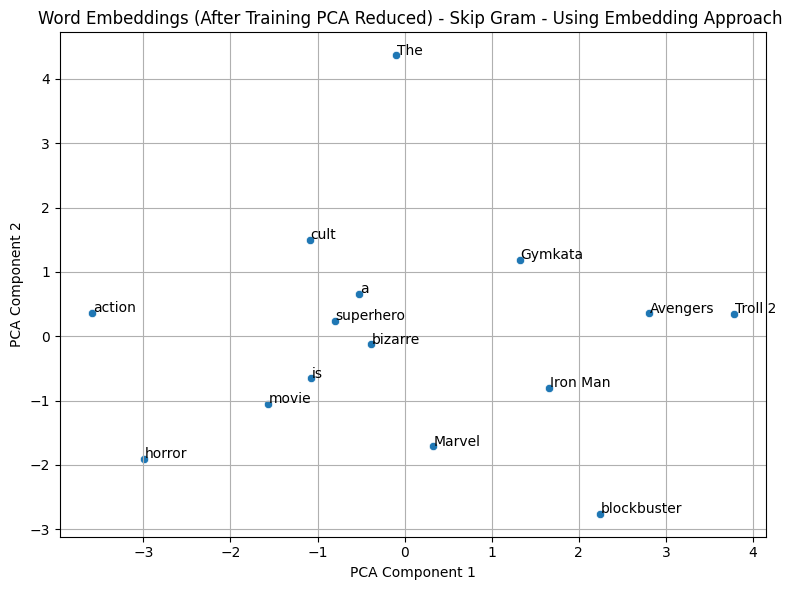

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.scatterplot(data=df, x="w1", y="w2")

for i in range(len(df)):
    plt.text(df["w1"][i] + 0.01,
             df["w2"][i] + 0.01,
             df["token"][i],
             fontsize=10)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Word Embeddings (After Training PCA Reduced) - Skip Gram - Using Embedding Approach ")

plt.grid(True)
plt.tight_layout()
plt.show()

## Reason:
“Skip-gram relies entirely on local co-occurrence. In a small dataset with limited shared context and low embedding dimension, the model captures surface-level statistical similarity rather than deeper semantic relationships.”

NumPy:

* works only with CPU memory
* has no understanding of GPU tensors


“NumPy operates on CPU memory, so tensors must be moved from GPU to CPU before conversion. Otherwise, it results in an error.”

How Word Embeddings Are Learned (CBOW & Skip-gram) — Small Experiment

In real-world systems, word embeddings are not manually designed. They are learned from large text corpora by observing how words appear together.
The core idea is simple:

Words that occur in similar contexts tend to have similar vector representations.

I explored this using a small controlled dataset and two standard methods: CBOW and Skip-gram.

⸻

Core Idea

Given a large corpus, we don’t assign meaning explicitly. Instead, we train a model to solve a prediction task:

* Either predict a word from its context
* Or predict context words from a given word

During this process, the model learns dense vector representations (embeddings).

⸻

Two Training Methods

1. CBOW (Continuous Bag of Words)

context words → predict center word

* Input: surrounding words
* Output: target word

Example:

"Troll 2 is a cult horror movie"
context: ["is", "a", "cult", "horror"] → predict "Troll 2"

* Context vectors are averaged (or summed)
* Works well when data is limited
* Faster to train

⸻

2. Skip-gram

center word → predict context words

* Input: one word
* Output: multiple surrounding words

Example:

"Troll 2" → ["is", "a"]

* Generates multiple training pairs
* Learns better representations for individual words
* More effective for capturing fine-grained relationships

⸻

What the Model Actually Learns

Both CBOW and Skip-gram optimize:

P(word | context)  or  P(context | word)

So embeddings capture:

statistical co-occurrence patterns, not explicit meaning

If two words appear in similar contexts across the corpus, their vectors become similar.

⸻

My Experiment

I used a small dataset:

* “Troll 2 is a cult horror movie”
* “Gymkata is a bizarre action movie”
* “The Avengers is a superhero blockbuster”
* “Iron Man is a Marvel superhero movie”

Goal:

* Check whether related words cluster together

⸻

Observations

Worked well

* Troll 2 ↔ Gymkata
    * Shared context: “is”, “a”, “movie”
    * Strong co-occurrence → similar embeddings

⸻

Did not work well

* Avengers ↔ Iron Man
    * Limited shared context
    * Appear in slightly different patterns

⸻

Key Insight

Embeddings reflect how words are used, not what they mean.

Even though “Iron Man” is part of “Avengers”, the model cannot learn this unless:

* They appear in similar contexts repeatedly
* Or are explicitly connected in data

⸻

Effect of Embedding Dimension

* Low dimension (e.g., 2D):
    * Too restrictive → poor separation
* Higher dimension (e.g., 10D):
    * More capacity → better structure

⸻

Visualization (PCA)

Since embeddings are high-dimensional, I used PCA to project them to 2D.

Important:

PCA is only for visualization. True relationships exist in higher dimensions.

⸻

Limitations (Important)

* Small dataset → weak learning signal
* Frequent words (“is”, “a”) dominate
* Missing relationships → not learned
* Visualization may hide structure

⸻

Final Understanding

Both CBOW and Skip-gram rely entirely on local co-occurrence.

In large datasets:

* This is enough to learn meaningful structure

In small datasets:

* The model captures surface-level statistical similarity, not deeper semantic relationships

⸻

Takeaway

* Word embeddings are learned representations from data, not predefined
* CBOW and Skip-gram differ in how they use context
* Data quality and diversity matter more than model complexity
* Similarity in embeddings = similarity in usage patterns

⸻

This experiment helped ground the theory:
embeddings are a function of data, not intuition.

Training Word Embeddings with CBOW and Skip-gram (Small Controlled Experiment)

I implemented a small experiment to understand how word embeddings are learned in practice, following three different approaches and comparing their behavior on a controlled dataset.

The goal was simple:
learn vector representations where semantically or contextually similar words are close in space.

⸻

Dataset

A small custom corpus:

* “Troll 2 is a cult horror movie”
* “Gymkata is a bizarre action movie”
* “The Avengers is a superhero blockbuster”
* “Iron Man is a Marvel superhero movie”

The intent was to check if relationships like:

* Troll 2 ↔ Gymkata
* Avengers ↔ Iron Man
* Iron Man ↔ superhero

emerge from training.

⸻

1. Three implementation approaches

Approach 1: From scratch (one-hot + weight matrix)

* Input tokens converted to one-hot vectors (size = vocab)
* Multiplied with a weight matrix → embeddings

one-hot × W = embedding

⸻

Approach 2: Linear layer

* Same idea implemented using:

nn.Linear(vocab_size, embedding_dim)

Key point:

A linear layer with one-hot input is mathematically equivalent to an embedding matrix.

⸻

Approach 3: Embedding + Linear (Word2Vec-style)

Embedding → Linear → Softmax

* nn.Embedding performs efficient index-based lookup
* No explicit one-hot creation
* This setup matches Skip-gram with full softmax

⸻

2. CBOW vs Skip-gram

I used:

* CBOW for first two approaches
* Skip-gram for the embedding-based model

Difference:

* CBOW:

context → predict center word

* Skip-gram:

center word → predict context

Observation:

Skip-gram provided better representations for individual words, especially in this small setup.

⸻

3. Embedding dimension

Initially:

embedding_dim = 2

This was too restrictive.

I increased it to:

embedding_dim = 10

Result:

* Better separation between words
* Improved similarity structure

Reason:

Higher dimensions allow the model to encode multiple relationships simultaneously instead of forcing everything into a compressed space.

⸻

4. PCA for visualization

Since embeddings are 10D, I used PCA:

PCA(n_components=2)

* Reduces 10D → 2D
* Preserves maximum variance for visualization

Important:

PCA is only for visualization. Actual relationships exist in the full 10D space.

⸻

5. Results and observations

What worked

* Troll 2 and Gymkata clustered together
    * Strong shared context: “is”, “a”, “movie”
* General grouping based on:
    * genre words
    * structural patterns

⸻

What didn’t fully work

* Avengers and Iron Man were not strongly aligned

Reason:

* Weak and asymmetric co-occurrence:

Avengers → blockbuster
Iron Man → Marvel, movie
(shared: superhero)

⸻

6. Key insight

Word embeddings in this setup are driven by local co-occurrence, not true semantic understanding.

So the model learns:

* Statistical similarity → ✅
* Conceptual relationships → limited

⸻

7. Limitations observed

1. Small dataset

* Only a few sentences
* Each relationship appears very few times
* No opportunity to generalize patterns

⸻

2. Context imbalance

Words like:

"is", "a"

appear frequently → dominate training

⸻

3. Weak relational signals

Relationships like:

Iron Man ∈ Avengers

are never explicitly reinforced in multiple contexts

⸻

4. Low-dimensional visualization

Even after PCA:

* Some relationships may not appear clearly
* Because projection loses information

⸻

8. Takeaways

* Embedding layer = efficient alternative to one-hot + linear
* Skip-gram captures better word-level representations than CBOW
* Embedding dimension directly affects quality
* PCA helps visualize but does not define similarity
* Local co-occurrence is the only learning signal

⸻

Final understanding

Both CBOW and Skip-gram rely entirely on local co-occurrence. In small datasets with limited context diversity and low embedding capacity, the model captures surface-level statistical similarity rather than deeper semantic relationships.

⸻

One limitation

The model struggled with relationships that were:

* conceptual but weakly represented
* or not repeated across different contexts

This is not a model issue, but a data limitation.

⸻

If you want to extend this further, the next meaningful step would be:

* introducing negative sampling
* or expanding the dataset to reinforce relationships explicitly